In [1]:
import math
import random
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('torch version:', torch.__version__)
print('device:', device)

torch version: 2.11.0+cpu
device: cpu


In [2]:
def tensor_info(name, tensor):
  return OrderedDict([
    ('name', name),
    ('shape', tuple(tensor.shape)), # 차원별 크기
    ('ndim', tensor.ndim),
    ('dtype', str(tensor.dtype).replace('torch.', '')),
    ('numel', tensor.numel()),
    ('is_contiguous', tensor.is_contiguous()),
    ('stride', tuple(tensor.stride())), # 메모리를 몇개씩 건너 뛰는지
  ])

def show_tensor_info(*named_tensors):
  rows = [tensor_info(name, tensor) for name, tensor in named_tensors]
  display(pd.DataFrame(rows))

def show_shape(name, tensor):
  print(f'{name:28s} shape={tuple(tensor.shape)}, ndim={tensor.ndim}, dtype={tensor.dtype}, stride={tuple(tensor.stride())}')

In [3]:
scalar = torch.tensor(3.14)
vector = torch.tensor([1.0, 2.0, 3.0])
matrix = torch.arange(6).reshape(2, 3)
tensor_3d = torch.arange(24).reshape(2, 3, 4)
image_batch = torch.randn(8, 3, 32, 32) # NCHW: batch, channel, height, width
sequence_batch = torch.randn(8, 12, 128) # batch, sequence_length, embedding_dim
classification_logits = torch.randn(8, 10) # batch, num_classes

show_tensor_info(
    ('scalar', scalar),
    ('vector', vector),
    ('matrix', matrix),
    ('tensor_3d', tensor_3d),
    ('image_batch', image_batch), # 8개 미니배치, 3채널, 32*32
    ('sequence_batch', sequence_batch),
    ('classification_logits', classification_logits),
)

,name,shape,ndim,dtype,numel,is_contiguous,stride
0,scalar,(),0,float32,1,True,()
1,vector,"(3,)",1,float32,3,True,"(1,)"
2,matrix,"(2, 3)",2,int64,6,True,"(3, 1)"
3,tensor_3d,"(2, 3, 4)",3,int64,24,True,"(12, 4, 1)"
4,image_batch,"(8, 3, 32, 32)",4,float32,24576,True,"(3072, 1024, 32, 1)"
5,sequence_batch,"(8, 12, 128)",3,float32,12288,True,"(1536, 128, 1)"
6,classification_logits,"(8, 10)",2,float32,80,True,"(10, 1)"


In [4]:
manual_numel = 8 * 3 * 32 * 32
print('manual_numel:', manual_numel)
print('image_batch.numel():', image_batch.numel())
print('same:', manual_numel == image_batch.numel()) # 산술적으로 계산한거랑 같음

manual_numel: 24576
image_batch.numel(): 24576
same: True


In [5]:
x = torch.arange(24).reshape(2, 3, 4)
print(x)
show_tensor_info(('x', x))

reduction_rows = []
for expr, value in [
    ('x.sum()', x.sum()),
    ('x.sum(dim=0)', x.sum(dim=0)),
    ('x.sum(dim=1)', x.sum(dim=1)),
    ('x.sum(dim=2)', x.sum(dim=2)),
    ('x.mean(dim=1)', x.float().mean(dim=1)),
    ('x.max(dim=2).values', x.max(dim=2).values),
    ('x.argmax(dim=2)', x.argmax(dim=2)),
]:
    reduction_rows.append({
      'operation': expr,
      'result_shape': tuple(value.shape),
      'result_ndim': value.ndim,
      'dtype': str(value.dtype).replace('torch.', ''),
    })


display(pd.DataFrame(reduction_rows))

tensor([[[ 0,  1,  2,  3],
         [ 4,  5,  6,  7],
         [ 8,  9, 10, 11]],

        [[12, 13, 14, 15],
         [16, 17, 18, 19],
         [20, 21, 22, 23]]])


,name,shape,ndim,dtype,numel,is_contiguous,stride
0,x,"(2, 3, 4)",3,int64,24,True,"(12, 4, 1)"


,operation,result_shape,result_ndim,dtype
0,x.sum(),(),0,int64
1,x.sum(dim=0),"(3, 4)",2,int64
2,x.sum(dim=1),"(2, 4)",2,int64
3,x.sum(dim=2),"(2, 3)",2,int64
4,x.mean(dim=1),"(2, 4)",2,float32
5,x.max(dim=2).values,"(2, 3)",2,int64
6,x.argmax(dim=2),"(2, 3)",2,int64


In [6]:
scores = torch.tensor([
    [1.2, -0.3, 2.5, 0.7],
    [-1.0, 3.1, 0.2, 2.9],
])

max_values, max_indices = scores.max(dim=1)
argmax_indices = scores.argmax(dim=1)

print('scores shape:', scores.shape)
print('max_values:', max_values)
print('max_indices:', max_indices)
print('argmax_indices:', argmax_indices)

scores shape: torch.Size([2, 4])
max_values: tensor([2.5000, 3.1000])
max_indices: tensor([2, 1])
argmax_indices: tensor([2, 1])


In [7]:
y = torch.arange(12).reshape(3, 4).float()

row_mean_no_keepdim = y.mean(dim=1)
row_mean_keepdim = y.mean(dim=1, keepdim=True) # 차원이 없어지지 않고 크기가 1인채로 유지됨

show_tensor_info(
    ('y', y),
    ('row_mean_no_keepdim', row_mean_no_keepdim),
    ('row_mean_keepdim', row_mean_keepdim),
)


print('y')
print(y)
print('\nrow_mean_no_keepdim')
print(row_mean_no_keepdim)
print('\nrow_mean_keepdim')
print(row_mean_keepdim)

,name,shape,ndim,dtype,numel,is_contiguous,stride
0,y,"(3, 4)",2,float32,12,True,"(4, 1)"
1,row_mean_no_keepdim,"(3,)",1,float32,3,True,"(1,)"
2,row_mean_keepdim,"(3, 1)",2,float32,3,True,"(1, 1)"


y
tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]])

row_mean_no_keepdim
tensor([1.5000, 5.5000, 9.5000])

row_mean_keepdim
tensor([[1.5000],
        [5.5000],
        [9.5000]])


In [8]:
centered_correct = y - row_mean_keepdim # 이건 계산하려는거랑 차원을 자동으로 맞춰주지만
print('centered_correct')
print(centered_correct)

try:
  centered_error = y - row_mean_no_keepdim # 이건 차원을 맞출수가 없음
except RuntimeError as e:
  print('RuntimeError 발생:')
  print(e)

centered_correct
tensor([[-1.5000, -0.5000,  0.5000,  1.5000],
        [-1.5000, -0.5000,  0.5000,  1.5000],
        [-1.5000, -0.5000,  0.5000,  1.5000]])
RuntimeError 발생:
The size of tensor a (4) must match the size of tensor b (3) at non-singleton dimension 1


In [9]:
logits = torch.tensor([
    [2.0, 0.1, -1.0],
    [-0.5, 1.2, 0.3],
    [0.1, -0.2, 1.5],
])
target = torch.tensor([0, 1, 2])

loss_none = nn.CrossEntropyLoss(reduction='none')(logits, target) # 로짓과 타깃 간의 로스를 계산 (분포의 차이를 봄)
loss_sum = nn.CrossEntropyLoss(reduction='sum')(logits, target)
loss_mean = nn.CrossEntropyLoss(reduction='mean')(logits, target)

print('loss_none:', loss_none, 'shape:', tuple(loss_none.shape))
print('loss_sum:', loss_sum, 'shape:', tuple(loss_sum.shape))
print('loss_mean:', loss_mean, 'shape:', tuple(loss_mean.shape))
print('loss_none.sum():', loss_none.sum())
print('loss_none.mean():', loss_none.mean())


loss_none: tensor([0.1818, 0.4633, 0.3572]) shape: (3,)
loss_sum: tensor(1.0022) shape: ()
loss_mean: tensor(0.3341) shape: ()
loss_none.sum(): tensor(1.0022)
loss_none.mean(): tensor(0.3341)


In [10]:
single_image = torch.randn(1, 28, 28) # C, H, W
batched_image = single_image.unsqueeze(0) # N, C, H, W
# 특정 위치에 크기가 1인 차원을 삽입
# 그냥 squeeze는 크기가 1인 차원을 제거함

show_tensor_info(
    ('single_image', single_image),
    ('batched_image', batched_image),
)

,name,shape,ndim,dtype,numel,is_contiguous,stride
0,single_image,"(1, 28, 28)",3,float32,784,True,"(784, 28, 1)"
1,batched_image,"(1, 1, 28, 28)",4,float32,784,True,"(784, 784, 28, 1)"


In [11]:
batch_size_one_logits = torch.randn(1, 10)
unsafe_squeeze = batch_size_one_logits.squeeze()
safe_squeeze_channel = batched_image.squeeze(1)

show_tensor_info(
    ('batch_size_one_logits', batch_size_one_logits),
    ('unsafe_squeeze', unsafe_squeeze),
    ('batched_image', batched_image),
    ('safe_squeeze_channel', safe_squeeze_channel),
)

,name,shape,ndim,dtype,numel,is_contiguous,stride
0,batch_size_one_logits,"(1, 10)",2,float32,10,True,"(10, 1)"
1,unsafe_squeeze,"(10,)",1,float32,10,True,"(1,)"
2,batched_image,"(1, 1, 28, 28)",4,float32,784,True,"(784, 784, 28, 1)"
3,safe_squeeze_channel,"(1, 28, 28)",3,float32,784,True,"(784, 28, 1)"


In [12]:
features = torch.randn(4, 16, 5, 5) # N, C, H, W
flat_view = features.view(4, -1) # 기존 tensor의 storage를 다른 shape로 해석하는 view 생성
flat_reshape = features.reshape(4, -1) # 가능한 경우 view 반환, 불가능하면 복사본 반환
flat_flatten = torch.flatten(features, start_dim=1) # 지정한 차원 범위를 하나의 차원으로 펼치는 연산

show_tensor_info(
    ('features', features),
    ('flat_view', flat_view),
    ('flat_reshape', flat_reshape),
    ('flat_flatten', flat_flatten),
)

print('expected feature dimension:', 16 * 5 * 5)

,name,shape,ndim,dtype,numel,is_contiguous,stride
0,features,"(4, 16, 5, 5)",4,float32,1600,True,"(400, 25, 5, 1)"
1,flat_view,"(4, 400)",2,float32,1600,True,"(400, 1)"
2,flat_reshape,"(4, 400)",2,float32,1600,True,"(400, 1)"
3,flat_flatten,"(4, 400)",2,float32,1600,True,"(400, 1)"


expected feature dimension: 400


In [13]:
z = torch.arange(24).reshape(2, 3, 4)
z_perm = z.permute(0, 2, 1) # (2, 4, 3) 이 되어버림
show_tensor_info(('z', z), ('z_perm', z_perm))

try:
  z_bad_view = z_perm.view(2, -1)
except RuntimeError as e:
  print('view 실패 예시:')
  print(e)

z_reshape = z_perm.reshape(2, -1) # 복사본 생성
z_contiguous_view = z_perm.contiguous().view(2, -1)

show_tensor_info(
    ('z_reshape', z_reshape),
    ('z_contiguous_view', z_contiguous_view),
)

,name,shape,ndim,dtype,numel,is_contiguous,stride
0,z,"(2, 3, 4)",3,int64,24,True,"(12, 4, 1)"
1,z_perm,"(2, 4, 3)",3,int64,24,False,"(12, 1, 4)"


view 실패 예시:
view size is not compatible with input tensor's size and stride (at least one dimension spans across two contiguous subspaces). Use .reshape(...) instead.


,name,shape,ndim,dtype,numel,is_contiguous,stride
0,z_reshape,"(2, 12)",2,int64,24,True,"(12, 1)"
1,z_contiguous_view,"(2, 12)",2,int64,24,True,"(12, 1)"


In [14]:
mat = torch.arange(12).reshape(3, 4)
mat_t = mat.transpose(0, 1)

images_nchw = torch.randn(2, 3, 4, 5)
images_nhwc = images_nchw.permute(0, 2, 3, 1)
images_back = images_nhwc.permute(0, 3, 1, 2)

show_tensor_info(
    ('mat', mat),
    ('mat_t', mat_t),
    ('images_nchw', images_nchw),
    ('images_nhwc', images_nhwc),
    ('images_back', images_back),
)

,name,shape,ndim,dtype,numel,is_contiguous,stride
0,mat,"(3, 4)",2,int64,12,True,"(4, 1)"
1,mat_t,"(4, 3)",2,int64,12,False,"(1, 4)"
2,images_nchw,"(2, 3, 4, 5)",4,float32,120,True,"(60, 20, 5, 1)"
3,images_nhwc,"(2, 4, 5, 3)",4,float32,120,False,"(60, 5, 1, 20)"
4,images_back,"(2, 3, 4, 5)",4,float32,120,True,"(60, 20, 5, 1)"


In [15]:
print('images_nchw is contiguous:', images_nchw.is_contiguous())
print('images_nhwc is contiguous:', images_nhwc.is_contiguous())
print('images_nhwc_contiguous is contiguous:', images_nhwc.contiguous().is_contiguous())

show_tensor_info(
    ('images_nhwc', images_nhwc),
    ('images_nhwc.contiguous()', images_nhwc.contiguous()),
)

images_nchw is contiguous: True
images_nhwc is contiguous: False
images_nhwc_contiguous is contiguous: True


,name,shape,ndim,dtype,numel,is_contiguous,stride
0,images_nhwc,"(2, 4, 5, 3)",4,float32,120,False,"(60, 5, 1, 20)"
1,images_nhwc.contiguous(),"(2, 4, 5, 3)",4,float32,120,True,"(60, 15, 3, 1)"


In [16]:
x = torch.tensor([
    [1.0, 2.0, 3.0],
    [4.0, 5.0, 6.0],
    [7.0, 8.0, 9.0],
    [10.0, 11.0, 12.0],
])

feature_mean = x.mean(dim=0, keepdim=True)
x_centered = x - feature_mean

show_tensor_info(
    ('x', x),
    ('feature_mean', feature_mean),
    ('x_centered', x_centered),
)

print('feature_mean')
print(feature_mean)
print('x_centered')
print(x_centered)

,name,shape,ndim,dtype,numel,is_contiguous,stride
0,x,"(4, 3)",2,float32,12,True,"(3, 1)"
1,feature_mean,"(1, 3)",2,float32,3,True,"(3, 1)"
2,x_centered,"(4, 3)",2,float32,12,True,"(3, 1)"


feature_mean
tensor([[5.5000, 6.5000, 7.5000]])
x_centered
tensor([[-4.5000, -4.5000, -4.5000],
        [-1.5000, -1.5000, -1.5000],
        [ 1.5000,  1.5000,  1.5000],
        [ 4.5000,  4.5000,  4.5000]])


In [17]:
# 이미지 batch가 [N, C, H, W]구조일 때 channel별 평균과 표준편차는 [1, C, 1, 1] 형태로 만들면 모든 batch와 모든 공간 위치에 동일하게 적용됨.
images = torch.randn(2, 3, 4, 4)
channel_mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
channel_std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

normalized_images = (images - channel_mean) / channel_std

show_tensor_info(
    ('images', images),
    ('channel_mean', channel_mean),
    ('channel_std', channel_std),
    ('normalized_images', normalized_images),
)

,name,shape,ndim,dtype,numel,is_contiguous,stride
0,images,"(2, 3, 4, 4)",4,float32,96,True,"(48, 16, 4, 1)"
1,channel_mean,"(1, 3, 1, 1)",4,float32,3,True,"(3, 1, 1, 1)"
2,channel_std,"(1, 3, 1, 1)",4,float32,3,True,"(3, 1, 1, 1)"
3,normalized_images,"(2, 3, 4, 4)",4,float32,96,True,"(48, 16, 4, 1)"


In [18]:
# 다중분류기의 이론 구조
batch_size = 4
num_features = 5
num_classes = 3

X = torch.randn(batch_size, num_features)
classifier = nn.Linear(num_features, num_classes)
logits = classifier(X)
predicted_class = logits.argmax(dim=1)

show_tensor_info(
    ('X', X),
    ('classifier.weight', classifier.weight),
    ('classifier.bias', classifier.bias),
    ('logits', logits),
    ('predicted_class', predicted_class),
)

print('logits')
print(logits)
print('predicted_class:', predicted_class.tolist())
# classifier.weight의 shape는 (num_classes, num_features)임

,name,shape,ndim,dtype,numel,is_contiguous,stride
0,X,"(4, 5)",2,float32,20,True,"(5, 1)"
1,classifier.weight,"(3, 5)",2,float32,15,True,"(5, 1)"
2,classifier.bias,"(3,)",1,float32,3,True,"(1,)"
3,logits,"(4, 3)",2,float32,12,True,"(3, 1)"
4,predicted_class,"(4,)",1,int64,4,True,"(1,)"


logits
tensor([[-0.2381,  0.5526, -0.0197],
        [-0.0140, -0.4804,  0.3850],
        [-0.4618,  0.8389, -0.2313],
        [-0.2435,  0.6700, -0.6633]], grad_fn=<AddmmBackward0>)
predicted_class: [1, 2, 1, 1]


In [19]:
# Logit와 Softmax
# Logits는 softmax 이전의 정규화되지 않은 class score임. 값이 음수일 수도 있고, 각 행의 합이 1일 필요도 없음.
# Softmax는 class dimension을 따라 logits를 확률 분포로 변환하는 함수
# 다중분류에서 logits의 shape가 [N, C]이면 일반적으로 softmax(dim=1)을 사용함. dim=1이 class dimension

logits = torch.tensor([
    [2.0, -1.0, 0.5],
    [-0.2, 0.1, 3.0],
])

prob_dim1 = F.softmax(logits, dim=1)
prob_dim0 = F.softmax(logits, dim=0)

print('logits')
print(logits)
print('logits row sums:', logits.sum(dim=1))
print('\nsoftmax(dim=1)')
print(prob_dim1)
print('row sums:', prob_dim1.sum(dim=1))
print('\nsoftmax(dim=0)')
print(prob_dim0)
print('column sums:', prob_dim0.sum(dim=0))


logits
tensor([[ 2.0000, -1.0000,  0.5000],
        [-0.2000,  0.1000,  3.0000]])
logits row sums: tensor([1.5000, 2.9000])

softmax(dim=1)
tensor([[0.7856, 0.0391, 0.1753],
        [0.0372, 0.0502, 0.9126]])
row sums: tensor([1., 1.])

softmax(dim=0)
tensor([[0.9002, 0.2497, 0.0759],
        [0.0998, 0.7503, 0.9241]])
column sums: tensor([1., 1., 1.])


In [20]:
target = torch.tensor([0, 2])
ce = nn.CrossEntropyLoss() # 입력으로 logit을 받음

loss_from_logits = ce(logits, target)
loss_from_softmax_output = ce(F.softmax(logits, dim=1), target) # 이건 softmax된 결과를 넣는거라 이러면 안됌

print('CrossEntropyLoss(logits, target):', float(loss_from_logits))
print('CrossEntropyLoss(softmax(logits), target):', float(loss_from_softmax_output))

log_probs = F.log_softmax(logits, dim=1)
manual_ce = -log_probs[torch.arange(target.numel()), target].mean()
print('manual CE from log_softmax:', float(manual_ce))

CrossEntropyLoss(logits, target): 0.16639134287834167
CrossEntropyLoss(softmax(logits), target): 0.65543133020401
manual CE from log_softmax: 0.16639134287834167


In [21]:
# One-Hot Encoding
labels = torch.tensor([2, 0, 1, 3])
one_hot_labels = F.one_hot(labels, num_classes=4)

show_tensor_info(
    ('labels', labels),
    ('one_hot_labels', one_hot_labels),
)

print('labels:', labels)
print('one_hot_labels')
print(one_hot_labels)

,name,shape,ndim,dtype,numel,is_contiguous,stride
0,labels,"(4,)",1,int64,4,True,"(1,)"
1,one_hot_labels,"(4, 4)",2,int64,16,True,"(4, 1)"


labels: tensor([2, 0, 1, 3])
one_hot_labels
tensor([[0, 0, 1, 0],
        [1, 0, 0, 0],
        [0, 1, 0, 0],
        [0, 0, 0, 1]])


In [22]:
logits = torch.tensor([
    [0.1, 0.2, 2.0, -1.0],
    [2.5, 0.3, -0.2, 0.0],
    [-1.0, 1.7, 0.2, 0.1],
    [0.0, -0.5, 0.2, 1.5],
])

ce_index = nn.CrossEntropyLoss()(logits, labels)
log_probs = F.log_softmax(logits, dim=1)
ce_one_hot_manual = -(one_hot_labels.float() * log_probs).sum(dim=1).mean()

print('CE with class index target:', float(ce_index))
print('manual CE with one-hot target:', float(ce_one_hot_manual))


CE with class index target: 0.35788801312446594
manual CE with one-hot target: 0.35788804292678833


In [23]:
multi_label_logits = torch.tensor([
    [2.0, -1.0, 0.5, 1.2],
    [-0.5, 1.5, 2.2, -2.0],
    [0.1, 0.2, -0.3, 3.0],
])
multi_label_targets = torch.tensor([
    [1.0, 0.0, 1.0, 0.0],
    [0.0, 1.0, 1.0, 0.0],
    [0.0, 0.0, 0.0, 1.0],
])

bce_logits_loss = nn.BCEWithLogitsLoss()(multi_label_logits, multi_label_targets)
sigmoid_probs = torch.sigmoid(multi_label_logits)

show_tensor_info(
    ('multi_label_logits', multi_label_logits),
    ('multi_label_targets', multi_label_targets),
    ('sigmoid_probs', sigmoid_probs),
)

print('BCEWithLogitsLoss:', float(bce_logits_loss))
print('sigmoid probabilities')
print(sigmoid_probs)


,name,shape,ndim,dtype,numel,is_contiguous,stride
0,multi_label_logits,"(3, 4)",2,float32,12,True,"(4, 1)"
1,multi_label_targets,"(3, 4)",2,float32,12,True,"(4, 1)"
2,sigmoid_probs,"(3, 4)",2,float32,12,True,"(4, 1)"


BCEWithLogitsLoss: 0.45254412293434143
sigmoid probabilities
tensor([[0.8808, 0.2689, 0.6225, 0.7685],
        [0.3775, 0.8176, 0.9002, 0.1192],
        [0.5250, 0.5498, 0.4256, 0.9526]])


In [24]:
loss_table = pd.DataFrame([
  {
    '문제 유형': '회귀',
    '모델 출력': '[N, D] 실수값',
    'Target': '[N, D] 실수값',
    '대표 loss': 'MSELoss, L1Loss, SmoothL1Loss',
    '해석': '예측값과 연속형 target의 거리 최소화',
  },
  {
    '문제 유형': '이진분류',
    '모델 출력': '[N] 또는 [N, 1] logits',
    'Target': '0/1 float',
    '대표 loss': 'BCEWithLogitsLoss',
    '해석': '하나의 class에 대한 양성 확률 학습',
  },
  {
    '문제 유형': '다중분류',
    '모델 출력': '[N, C] logits',
    'Target': '[N] class index',
    '대표 loss': 'CrossEntropyLoss',
    '해석': '여러 class 중 하나의 정답 class 학습',
  },
  {
    '문제 유형': '다중라벨분류',
    '모델 출력': '[N, C] logits',
    'Target': '[N, C] multi-hot float',
    '대표 loss': 'BCEWithLogitsLoss',
    '해석': 'class별 독립 binary classification',
  },
  {
    '문제 유형': 'Semantic segmentation',
    '모델 출력': '[N, C, H, W] logits',
    'Target': '[N, H, W] class index',
    '대표 loss': 'CrossEntropyLoss',
    '해석': 'pixel별 다중분류',
  },
])

display(loss_table)

,문제 유형,모델 출력,Target,대표 loss,해석
0,회귀,"[N, D] 실수값","[N, D] 실수값","MSELoss, L1Loss, SmoothL1Loss",예측값과 연속형 target의 거리 최소화
1,이진분류,"[N] 또는 [N, 1] logits",0/1 float,BCEWithLogitsLoss,하나의 class에 대한 양성 확률 학습
2,다중분류,"[N, C] logits",[N] class index,CrossEntropyLoss,여러 class 중 하나의 정답 class 학습
3,다중라벨분류,"[N, C] logits","[N, C] multi-hot float",BCEWithLogitsLoss,class별 독립 binary classification
4,Semantic segmentation,"[N, C, H, W] logits","[N, H, W] class index",CrossEntropyLoss,pixel별 다중분류


In [25]:
 # 회귀: MSELoss
pred_reg = torch.tensor([[2.5, 0.0], [1.0, -1.0]])
target_reg = torch.tensor([[3.0, 0.5], [0.0, -1.5]])
print('MSELoss:', float(nn.MSELoss()(pred_reg, target_reg)))
print('L1Loss:', float(nn.L1Loss()(pred_reg, target_reg)))
print('SmoothL1Loss:', float(nn.SmoothL1Loss()(pred_reg, target_reg)))

# 이진분류: BCEWithLogitsLoss
binary_logits = torch.tensor([2.0, -1.0, 0.0])
binary_target = torch.tensor([1.0, 0.0, 1.0])
print('BCEWithLogitsLoss:', float(nn.BCEWithLogitsLoss()(binary_logits, binary_target)))

# 다중분류: CrossEntropyLoss
multi_logits = torch.tensor([[2.0, 0.1, -1.0], [-0.5, 1.2, 0.3]])
multi_target = torch.tensor([0, 1])
print('CrossEntropyLoss:', float(nn.CrossEntropyLoss()(multi_logits, multi_target)))

# NLLLoss: log_softmax 이후 사용
log_prob = F.log_softmax(multi_logits, dim=1)
print('NLLLoss(log_softmax(logits)):', float(nn.NLLLoss()(log_prob, multi_target)))

MSELoss: 0.4375
L1Loss: 0.625
SmoothL1Loss: 0.21875
BCEWithLogitsLoss: 0.3777790069580078
CrossEntropyLoss: 0.3225243091583252
NLLLoss(log_softmax(logits)): 0.3225243091583252


In [26]:
# 같은 [N, C] 출력이라도 문제 설정에 따라 loss가 달라지는 예시
logits_nc = torch.tensor([
    [1.5, -0.3, 0.2],
    [-0.2, 2.0, 0.4],
])

# 다중분류 target: 각 sample당 하나의 class index
class_index_target = torch.tensor([0, 1])

# 다중라벨 target: 각 sample당 여러 class가 동시에 1일 수 있음
multi_hot_target = torch.tensor([
    [1.0, 0.0, 1.0],
     [0.0, 1.0, 1.0],
])

loss_multiclass = nn.CrossEntropyLoss()(logits_nc, class_index_target)
loss_multilabel = nn.BCEWithLogitsLoss()(logits_nc, multi_hot_target)

print('multi-class CE:', float(loss_multiclass))
print('multi-label BCEWithLogits:', float(loss_multilabel))

multi-class CE: 0.3176106810569763
multi-label BCEWithLogits: 0.43199825286865234


,name,shape,ndim,dtype,numel,is_contiguous,stride
0,X_toy,"(360, 2)",2,float32,720,True,"(2, 1)"
1,y_toy,"(360,)",1,int64,360,True,"(1,)"


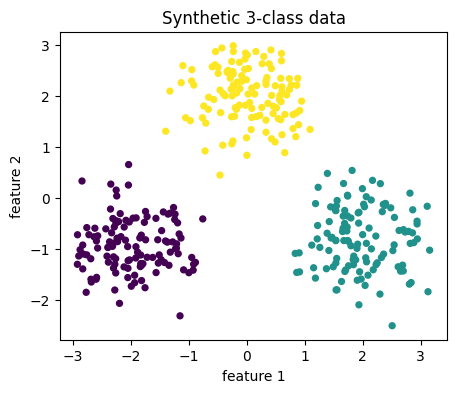

In [27]:
#  3‑class toy classifier
def make_three_class_data(n_per_class=120, noise=0.55):
  centers = torch.tensor([
      [-2.0, -1.0],
      [2.0, -0.8],
      [0.0, 2.0],
  ])

  X_list, y_list = [], []
  for class_id, center in enumerate(centers):
      points = center + noise * torch.randn(n_per_class, 2)
      labels = torch.full((n_per_class,), class_id, dtype=torch.long)
      X_list.append(points)
      y_list.append(labels)
  X = torch.cat(X_list, dim=0)
  y = torch.cat(y_list, dim=0)
  perm = torch.randperm(X.size(0))
  return X[perm], y[perm]


X_toy, y_toy = make_three_class_data()
show_tensor_info(('X_toy', X_toy), ('y_toy', y_toy))

plt.figure(figsize=(5, 4))
plt.scatter(X_toy[:, 0], X_toy[:, 1], c=y_toy, s=18)
plt.title('Synthetic 3-class data')
plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.show()

In [28]:
class LinearClassifier(nn.Module):
  def __init__(self, in_features=2, num_classes=3):
      super().__init__()
      self.linear = nn.Linear(in_features, num_classes)
  def forward(self, x):
      return self.linear(x)

model = LinearClassifier().to(device)
X_toy_device = X_toy.to(device)
y_toy_device = y_toy.to(device)

with torch.no_grad():
    initial_logits = model(X_toy_device[:5])
    initial_probs = F.softmax(initial_logits, dim=1)
    initial_pred = initial_logits.argmax(dim=1)

show_tensor_info(
    ('initial_logits', initial_logits.cpu()),
    ('initial_probs', initial_probs.cpu()),
    ('initial_pred', initial_pred.cpu()),
)

print('initial_logits')
print(initial_logits.cpu())
print('initial_probs')
print(initial_probs.cpu())
print('initial_pred:', initial_pred.cpu().tolist())
print('target:', y_toy[:5].tolist())


,name,shape,ndim,dtype,numel,is_contiguous,stride
0,initial_logits,"(5, 3)",2,float32,15,True,"(3, 1)"
1,initial_probs,"(5, 3)",2,float32,15,True,"(3, 1)"
2,initial_pred,"(5,)",1,int64,5,True,"(1,)"


initial_logits
tensor([[-0.0808,  1.5360,  0.8200],
        [-0.1889,  1.7740,  0.7099],
        [-0.2549,  1.9086,  0.8040],
        [ 0.8916, -0.5162,  0.4826],
        [ 0.8916, -0.4499, -0.5039]])
initial_probs
tensor([[0.1177, 0.5927, 0.2897],
        [0.0945, 0.6732, 0.2323],
        [0.0795, 0.6914, 0.2291],
        [0.5238, 0.1282, 0.3480],
        [0.6626, 0.1732, 0.1641]])
initial_pred: [1, 1, 1, 0, 0]
target: [1, 1, 1, 2, 0]


In [29]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.15)
criterion = nn.CrossEntropyLoss()

history = []
num_epochs = 120

for epoch in range(1, num_epochs + 1):
    model.train()
    logits = model(X_toy_device)
    loss = criterion(logits, y_toy_device)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        pred = logits.argmax(dim=1)
        acc = (pred == y_toy_device).float().mean()

    history.append({'epoch': epoch, 'loss': float(loss.item()), 'accuracy': float(acc.item())})
history_df = pd.DataFrame(history)
display(history_df.iloc[[0, 1, 2, 9, 29, 59, 119]])

,epoch,loss,accuracy
0,1,0.587972,0.786111
1,2,0.507671,0.872222
2,3,0.444412,0.941667
9,10,0.235749,0.994444
29,30,0.109405,1.000000
59,60,0.065770,1.000000
119,120,0.039587,1.000000


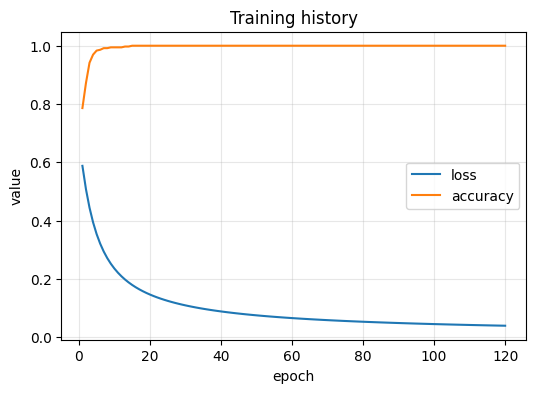

In [30]:
plt.figure(figsize=(6, 4))
plt.plot(history_df['epoch'], history_df['loss'], label='loss')
plt.plot(history_df['epoch'], history_df['accuracy'], label='accuracy')
plt.xlabel('epoch')
plt.ylabel('value')
plt.title('Training history')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [31]:
model.eval()
with torch.no_grad():
  final_logits = model(X_toy_device)
  final_probs = F.softmax(final_logits, dim=1)
  final_pred = final_logits.argmax(dim=1)
  final_acc = (final_pred == y_toy_device).float().mean().item()

print('final accuracy:', final_acc)
print('first five final logits')
print(final_logits[:5].cpu())
print('first five final probabilities')
print(final_probs[:5].cpu())
print('first five predictions:', final_pred[:5].cpu().tolist())
print('first five targets:', y_toy[:5].tolist())

final accuracy: 1.0
first five final logits
tensor([[-1.6569,  3.1779,  0.7543],
        [-0.9863,  3.9120, -0.6306],
        [-1.3712,  4.2137, -0.3848],
        [-1.1494, -2.2177,  4.2251],
        [ 3.7114, -1.3199, -2.4538]])
first five final probabilities
tensor([[0.0072, 0.9120, 0.0808],
        [0.0073, 0.9822, 0.0105],
        [0.0037, 0.9864, 0.0099],
        [0.0046, 0.0016, 0.9938],
        [0.9914, 0.0065, 0.0021]])
first five predictions: [1, 1, 1, 2, 0]
first five targets: [1, 1, 1, 2, 0]


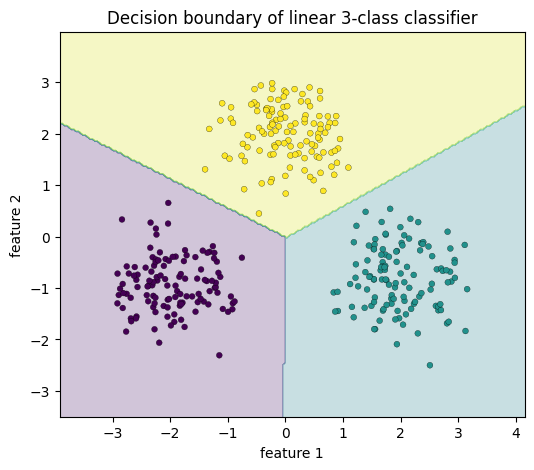

In [32]:
def plot_decision_boundary(model, X, y, device):
  model.eval()
  x_min, x_max = X[:, 0].min().item() - 1.0, X[:, 0].max().item() + 1.0
  y_min, y_max = X[:, 1].min().item() - 1.0, X[:, 1].max().item() + 1.0

  xx, yy = torch.meshgrid(
      torch.linspace(x_min, x_max, 200),
      torch.linspace(y_min, y_max, 200),
      indexing='xy',
  )
  grid = torch.stack([xx.reshape(-1), yy.reshape(-1)], dim=1).to(device)

  with torch.no_grad():
      pred = model(grid).argmax(dim=1).cpu().reshape(xx.shape)

  plt.figure(figsize=(6, 5))
  plt.contourf(xx.numpy(), yy.numpy(), pred.numpy(), alpha=0.25)
  plt.scatter(X[:, 0], X[:, 1], c=y, s=18, edgecolors='k', linewidths=0.2)
  plt.title('Decision boundary of linear 3-class classifier')
  plt.xlabel('feature 1')
  plt.ylabel('feature 2')
  plt.show()

plot_decision_boundary(model, X_toy, y_toy, device)

,pred 0,pred 1,pred 2
true 0,120,0,0
true 1,0,120,0
true 2,0,0,120


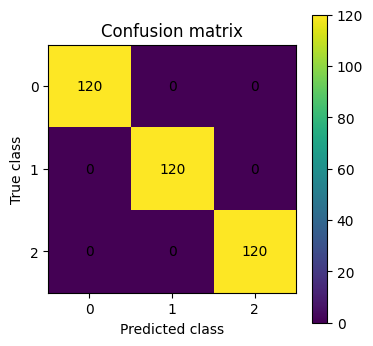

In [33]:
def confusion_matrix_torch(y_true, y_pred, num_classes):
  cm = torch.zeros(num_classes, num_classes, dtype=torch.int64)
  for t, p in zip(y_true.cpu(), y_pred.cpu()):
    cm[t.long(), p.long()] += 1
  return cm

cm = confusion_matrix_torch(y_toy_device, final_pred, num_classes=3)
cm_df = pd.DataFrame(cm.numpy(), index=['true 0', 'true 1', 'true 2'], columns=['pred 0', 'pred 1', 'pred 2'])
display(cm_df)

plt.figure(figsize=(4, 4))
plt.imshow(cm.numpy())
plt.title('Confusion matrix')
plt.xlabel('Predicted class')
plt.ylabel('True class')
plt.xticks([0, 1, 2])
plt.yticks([0, 1, 2])
for i in range(3):
  for j in range(3):
    plt.text(j, i, int(cm[i, j]), ha='center', va='center')
plt.colorbar()
plt.show()
